In [92]:
# Phase 1: Project Setup

In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [94]:
# Load the dataset
df = pd.read_csv("data/Advertising.csv")

In [95]:
df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [96]:
df.tail()

,Unnamed: 0,TV,Radio,Newspaper,Sales
195,196,38.2,3.7,13.8,7.6
196,197,94.2,4.9,8.1,9.7
197,198,177.0,9.3,6.4,12.8
198,199,283.6,42.0,66.2,25.5
199,200,232.1,8.6,8.7,13.4


In [97]:
# Phase 2: Understanding the Dataset

In [98]:
# Number of rows and columns
df.shape

(200, 5)

In [99]:
# Display column names
df.columns

Index(['Unnamed: 0', 'TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')

In [100]:
# Information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [101]:
# Summary statistics
df.describe()

,Unnamed: 0,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


In [102]:
# Count missing values in each column
df.isnull().sum()

Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64

In [103]:
# Phase 3: Data Cleaning & Preparation

In [104]:
# Remove the unnecessary column
df = df.drop("Unnamed: 0", axis=1)
# If we remove a column,USE AXIS = 1 , to remove a row , USE AXIS = 0

In [105]:
df.head()
# Verify the Column is Removed

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [106]:
df.columns

Index(['TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')

In [107]:
df.duplicated().sum()   #Check for Duplicate Rows

np.int64(0)

In [108]:
df = df.drop_duplicates()   #Remove Duplicates (Only if Needed)

In [109]:
df.shape  #FINAL SHAPE

(200, 4)

In [110]:
# Phase 4: Exploratory Data Analysis (EDA)

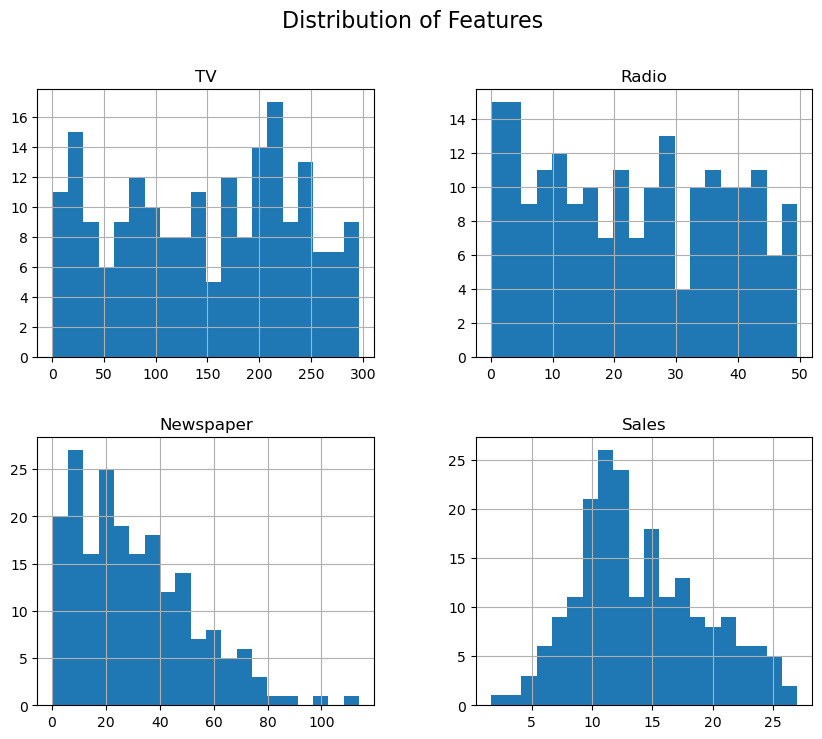

In [111]:
# Plot histograms for all numerical columns

df.hist(figsize=(10, 8), bins=20)  #bins=20 : Histogram groups values into intervals called bins.
plt.suptitle("Distribution of Features", fontsize=16)
plt.show()

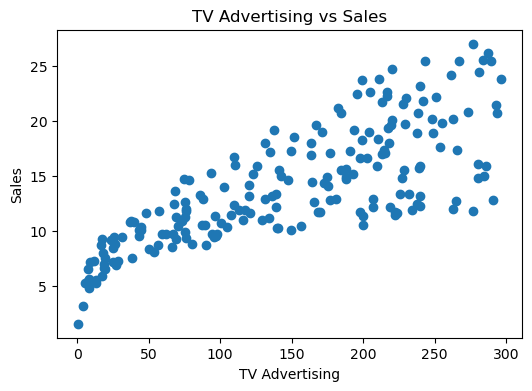

In [112]:
# Graph 2 : Scatter Plot : comparing

plt.figure(figsize=(6,4))
plt.scatter(df["TV"], df["Sales"])
plt.title("TV Advertising vs Sales")
plt.xlabel("TV Advertising")
plt.ylabel("Sales")
plt.show()

In [113]:
# TV = 230, Sales = 22 becomes •

# If dots go upward, It means more tv advertisements -> more sales = Positive relationship.
# If dots go downward, Negative relationship.
# If dots are everywhere, No relationship.

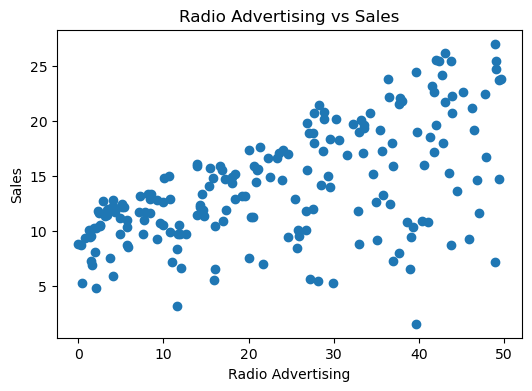

In [114]:
# Repeat for Radio

plt.figure(figsize=(6,4))
plt.scatter(df["Radio"], df["Sales"])
plt.title("Radio Advertising vs Sales")
plt.xlabel("Radio Advertising")
plt.ylabel("Sales")
plt.show()

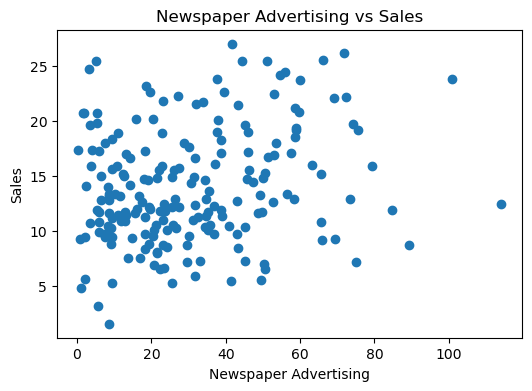

In [115]:
# Repeat for Newspaper

plt.figure(figsize=(6,4))
plt.scatter(df["Newspaper"], df["Sales"])
plt.title("Newspaper Advertising vs Sales")
plt.xlabel("Newspaper Advertising")
plt.ylabel("Sales")
plt.show()

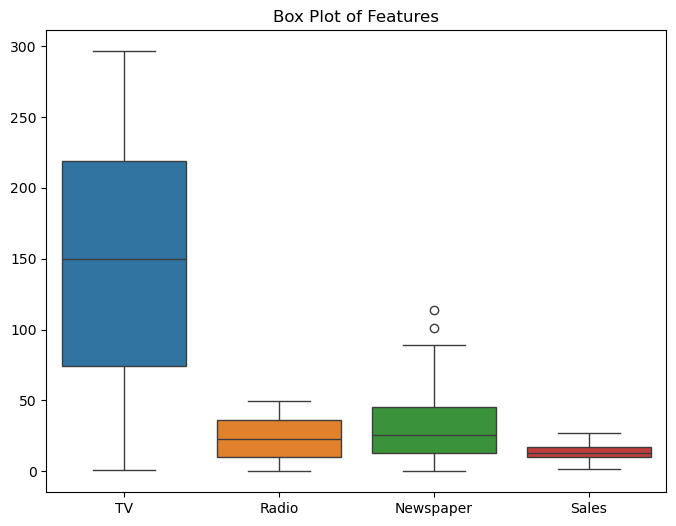

In [116]:
# Graph 3 : Box Plot - Find outliers.

plt.figure(figsize=(8,6))
sns.boxplot(data=df)
plt.title("Box Plot of Features")
plt.show()

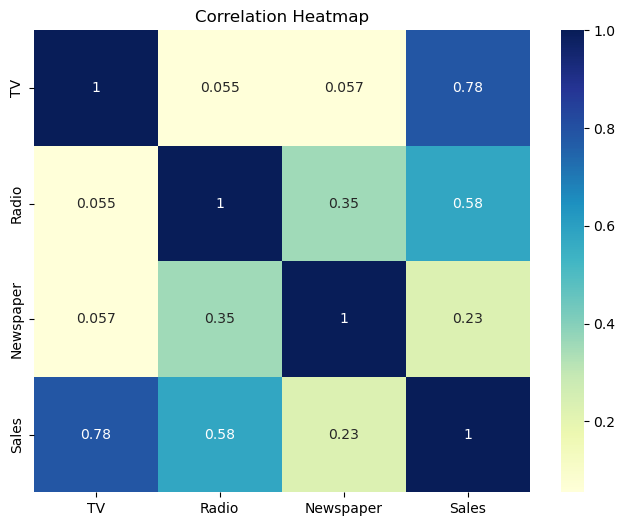

In [117]:
# Graph 4 : Correlation Heatmap - Which feature has the strongest relationship with Sales.

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="YlGnBu")
plt.title("Correlation Heatmap")
plt.show()

In [118]:
# Phase 5: Feature Selection and Train-Test Split

In [119]:
# Select input features
X = df[['TV', 'Radio', 'Newspaper']]

# Select target variable
y = df['Sales']

In [120]:
X.head() #VERIFY

,TV,Radio,Newspaper
0,230.1,37.8,69.2
1,44.5,39.3,45.1
2,17.2,45.9,69.3
3,151.5,41.3,58.5
4,180.8,10.8,58.4


In [121]:
y.head()   #VERIFY

0    22.1
1    10.4
2     9.3
3    18.5
4    12.9
Name: Sales, dtype: float64

In [122]:
from sklearn.model_selection import train_test_split

In [123]:
# Split the Dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2, # 20% goes to testing.
    random_state=42
)

In [124]:
print("X_train shape :", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape :", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape : (160, 3)
X_test shape : (40, 3)
y_train shape : (160,)
y_test shape : (40,)


In [125]:
# Phase 6: Building the Linear Regression Model

In [126]:
from sklearn.linear_model import LinearRegression

# Scikit-learn already provides the Linear Regression algorithm.
# Instead of writing the algorithm ourselves, we simply import it.

In [127]:
# Create the Model

model = LinearRegression()

In [128]:
model.fit(X_train, y_train)
# fit()-"Learn from the training data."

LinearRegression()

In [129]:
print("Coefficients:", model.coef_)
# Each feature gets a coefficient.
# Explanation : 
# If TV advertising increases by 1 unit, and Radio and Newspaper spending remain the same, the predicted Sales increase by about 0.04472952 units.
# 0.18919505 - Radio spending has a stronger positive effect on predicted Sales per unit increase, according to the model.
# 0.00276111 - This value is very small.

Coefficients: [0.04472952 0.18919505 0.00276111]


In [130]:
print("Intercept:", model.intercept_)  

# The intercept is the model's predicted Sales when tv=0, radio=0, newspaper=0

Intercept: 2.979067338122631


In [131]:
# Predicted Sales =
# 0.0447 × TV
# + 0.1892 × Radio
# + 0.0028 × Newspaper
# + 2.97


# Sales =
# (0.04472952 × 200)+(0.18919505 × 20)+(0.00276111 × 30)+ 2.97906734
# ≈ 15.79 units

In [132]:
# Match Features with Coefficients
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print(coefficients)

     Feature  Coefficient
0         TV     0.044730
1      Radio     0.189195
2  Newspaper     0.002761


In [133]:
# Phase 7: Making Predictions

In [134]:
# Predict sales on the test data
y_pred = model.predict(X_test)

# predict() - asks the trained model: "Based on everything you've learned, what sales do you think these advertising budgets will produce?"

# The model uses the equation it learned:
# Predicted Sales =
# (TV × coefficient)+
# (Radio × coefficient)+
# (Newspaper × coefficient)+
# Intercept

print(y_pred) #View the Predictions
#Each number is the predicted sales for one test record.

[16.4080242  20.88988209 21.55384318 10.60850256 22.11237326 13.10559172
 21.05719192  7.46101034 13.60634581 15.15506967  9.04831992  6.65328312
 14.34554487  8.90349333  9.68959028 12.16494386  8.73628397 16.26507258
 10.27759582 18.83109103 19.56036653 13.25103464 12.33620695 21.30695132
  7.82740305  5.80957448 20.75753231 11.98138077  9.18349576  8.5066991
 12.46646769 10.00337695 21.3876709  12.24966368 18.26661538 20.13766267
 14.05514005 20.85411186 11.0174441   4.56899622]


In [135]:
#Compare Actual vs Predicted

comparison = pd.DataFrame({
    "Actual Sales": y_test.values,
    "Predicted Sales": y_pred
})

comparison.head(10)

,Actual Sales,Predicted Sales
0,16.9,16.408024
1,22.4,20.889882
2,21.4,21.553843
3,7.3,10.608503
4,24.7,22.112373
5,12.6,13.105592
6,22.3,21.057192
7,8.4,7.461010
8,11.5,13.606346
9,14.9,15.155070


In [136]:
# Check the Number of Predictions

print("Number of predictions:", len(y_pred))

# Test Size = 20%
# 200 × 20% = 40 records

Number of predictions: 40


In [137]:
comparison.tail(10)  #last 10 predictions.

,Actual Sales,Predicted Sales
30,10.6,12.466468
31,11.3,10.003377
32,23.7,21.387671
33,8.7,12.249664
34,16.1,18.266615
35,20.7,20.137663
36,11.6,14.055140
37,20.8,20.854112
38,11.9,11.017444
39,6.9,4.568996


In [138]:
# Phase 8: Model Evaluation

In [139]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [140]:
# Calculate MAE

mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error (MAE):", mae)

Mean Absolute Error (MAE): 1.4607567168117597


In [141]:
# Calculate MSE

mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error (MSE):", mse)

Mean Squared Error (MSE): 3.1740973539761015


In [142]:
# Calculate RMSE

import numpy as np
rmse = np.sqrt(mse)
print("Root Mean Squared Error (RMSE):", rmse)

Root Mean Squared Error (RMSE): 1.7815996615334495


In [143]:
# Calculate R² Score

r2 = r2_score(y_test, y_pred)
print("R² Score:", r2)

R² Score: 0.8994380241009121


In [144]:
# Phase 9: Predict Sales for New Advertising Budgets

In [145]:
# New advertising budget
new_data = [[250, 30, 40]]

# Predict sales
prediction = model.predict(new_data)

print("Predicted Sales:", prediction[0])

Predicted Sales: 19.947742905987695


C:\Users\balla\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [146]:
# Take input from the user
tv = float(input("Enter TV advertising budget: "))
radio = float(input("Enter Radio advertising budget: "))
newspaper = float(input("Enter Newspaper advertising budget: "))

# Predict sales
prediction = model.predict([[tv, radio, newspaper]])

print(f"\nPredicted Sales: {prediction[0]:.2f}")

Enter TV advertising budget:  100
Enter Radio advertising budget:  125
Enter Newspaper advertising budget:  10



Predicted Sales: 31.13


C:\Users\balla\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [147]:
tv = float(input("Enter TV advertising budget: "))
radio = float(input("Enter Radio advertising budget: "))
newspaper = float(input("Enter Newspaper advertising budget: "))

prediction = model.predict([[tv, radio, newspaper]])

print("\n----------- Prediction Result -----------")
print(f"TV Advertising       : {tv}")
print(f"Radio Advertising    : {radio}")
print(f"Newspaper Advertising: {newspaper}")
print("-----------------------------------------")
print(f"Predicted Sales      : {prediction[0]:.2f}")

Enter TV advertising budget:  154
Enter Radio advertising budget:  200
Enter Newspaper advertising budget:  12



----------- Prediction Result -----------
TV Advertising       : 154.0
Radio Advertising    : 200.0
Newspaper Advertising: 12.0
-----------------------------------------
Predicted Sales      : 47.74


C:\Users\balla\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [148]:
# Successfully completed the Sales Prediction using Python project.